In [1]:
from QLBM import QLBM, collision, InitializeQC
from QLBM_1 import QLBM1, collision1, InitializeQC1
from QLBM_2 import QLBM2, collision2, InitializeQC2
import numpy as np
import matplotlib.pyplot as plt
import qiskit_aer
from qiskit import transpile

In [2]:
# Domain and grid setup
N_POINTS_X, N_POINTS_Y = 16, 16
x_0 = np.arange(N_POINTS_X)
y_0 = np.arange(N_POINTS_Y)
X, Y = np.meshgrid(x_0, y_0)  # Create a 2D grid

# Simulation parameters
TIMESTEPS = 1000000
NUMBER_DISCRETE_VELOCITIES = 9  # D2Q9 lattice configuration

In [3]:
Q = 9
Nx = N_POINTS_X-1
Ny = N_POINTS_Y-1
dx = dy = 1.0
dt = dx
c = dt/dx
Re = 100
f_eq = np.zeros((Nx+1, Ny+1, Q))
f = np.zeros((Nx+1, Ny+1, Q))

Lx = dx * float(Nx)
Ly = dy * float(Ny)
U = 0.1
cs = np.sqrt(c**2/3)
nu = 1/2*dt*cs**2

tau_f = 1.0
rho_0 = 1.0
rho = np.zeros((Nx+1, Ny+1))
u = np.zeros((Nx+1, Ny+1, 2))
e = np.array([[0, 0], [1, 0], [0, 1], [-1, 0], [0, -1], [1, 1], [-1, 1], [-1, -1], [1, -1]])
w = np.array([4.0/9, 1.0/9, 1.0/9, 1.0/9, 1.0/9, 1.0/36, 1.0/36, 1.0/36, 1.0/36])
u_n = u[:, :, 0].copy()
v_n = u[:, :, 1].copy() 
u_t = np.zeros((Nx+3, Ny+3))
v_t = np.zeros((Nx+3, Ny+3))
A = 3/4 - 9/2*U*Lx*dx/Re
rho[:, :] = rho_0
u[:, Ny, 0] = U
print(Nx+1)
q_error=[]
c_error=[]
qc_error=[]

16


In [4]:
## Initial
rho[:, :] = rho_0
u[:, Ny, 0] = U

In [5]:
simulator = qiskit_aer.backends.statevector_simulator.StatevectorSimulator()
simulator1 = qiskit_aer.backends.statevector_simulator.StatevectorSimulator()
simulator2 = qiskit_aer.backends.statevector_simulator.StatevectorSimulator()

In [6]:
# Initialize the quantum LBM scalar field
Psi_qlbm = np.zeros((TIMESTEPS + 1, N_POINTS_X, N_POINTS_Y))
Psi_qlbm1 = np.zeros((TIMESTEPS + 1, N_POINTS_X, N_POINTS_Y))
Psi_qlbm2 = np.zeros((TIMESTEPS + 1, N_POINTS_X, N_POINTS_Y))
Psi_qlbm[0, :, :] = rho_0#Psi_init
Psi_qlbm1[0, :, :] = u[:,:,0].copy()#Psi_init
Psi_qlbm2[0, :, :] = u[:,:,1].copy()#Psi_init
Psi_qlbm0 = Psi_qlbm[0,:,:].copy()
u_LBM = np.zeros((N_POINTS_X, N_POINTS_Y, 2))
u_LBM[:, :, 0] = Psi_qlbm1[0,:,:]  # Set the x-component of the velocity
u_LBM[:, :, 1] = Psi_qlbm2[0,:,:]  # Set the y-component of the velocity

# Quantum LBM simulation loop
for t in range(TIMESTEPS):
    u_t[1:-1,1:-1] = u[:,:,0].copy()
    v_t[1:-1,1:-1] = u[:,:,1].copy()
    u_t[1:-1,0] = - u[:,1,0].copy()
    u_t[0,1:-1] = - u[1,:,0].copy()
    u_t[-1,1:-1] = - u[-2,:,0].copy()
    u_t[1:-1,-1] = 2.0*U - u[:,-2,0].copy()
    v_t[1:-1,0] = - u[:,1,1].copy()
    v_t[0,1:-1] = - u[1,:,1].copy()
    v_t[-1,1:-1] = - u[-2,:,1].copy()
    v_t[1:-1,-1] = - u[:,-2,1].copy()
    u_t_y = (u_t[1:-1, 2:] - u_t[1:-1, :-2])/(2.0*dy)
    u_t_x = (u_t[2:, 1:-1] - u_t[:-2, 1:-1])/(2.0*dx)
    v_t_y = (v_t[1:-1, 2:] - v_t[1:-1, :-2])/(2.0*dy)
    v_t_x = (v_t[2:, 1:-1] - v_t[:-2, 1:-1])/(2.0*dx)


    temp = u[:, :, 0] * u[:, :, 0] + u[:, :, 1] * u[:, :, 1]
    f_eq[:, :, 0] = w[0] * rho* (1.0 + 3.0 * (e[0, 0] * u[:, :, 0] + e[0, 1] * u[:, :, 1]) + 4.5 * (e[0, 0] * u[:, :, 0] + e[0, 1] * u[:, :, 1]) ** 2 - 1.5 * temp + A*dt*(u_t_y + v_t_x)*e[0,0]*e[0,1]+\
                                 A*dt*(u_t_x + u_t_x)*e[0,0]*e[0,0]+A*dt*(v_t_y + v_t_y)*e[0,1]*e[0,1]+A*dt*(u_t_y + v_t_x)*e[0,1]*e[0,0])
    f_eq[:, :, 1] = w[1] * rho* (1.0 + 3.0 * (e[1, 0] * u[:, :, 0] + e[1, 1] * u[:, :, 1]) + 4.5 * (e[1, 0] * u[:, :, 0] + e[1, 1] * u[:, :, 1]) ** 2 - 1.5 * temp + A*dt*(u_t_y + v_t_x)*e[1,0]*e[1,1]+\
                                 A*dt*(u_t_x + u_t_x)*e[1,0]*e[1,0]+A*dt*(v_t_y + v_t_y)*e[1,1]*e[1,1]+A*dt*(u_t_y + v_t_x)*e[1,1]*e[1,0])
    f_eq[:, :, 2] = w[2] * rho* (1.0 + 3.0 * (e[2, 0] * u[:, :, 0] + e[2, 1] * u[:, :, 1]) + 4.5 * (e[2, 0] * u[:, :, 0] + e[2, 1] * u[:, :, 1]) ** 2 - 1.5 * temp + A*dt*(u_t_y + v_t_x)*e[2,0]*e[2,1]+\
                                 A*dt*(u_t_x + u_t_x)*e[2,0]*e[2,0]+A*dt*(v_t_y + v_t_y)*e[2,1]*e[2,1]+A*dt*(u_t_y + v_t_x)*e[2,1]*e[2,0])
    f_eq[:, :, 3] = w[3] * rho* (1.0 + 3.0 * (e[3, 0] * u[:, :, 0] + e[3, 1] * u[:, :, 1]) + 4.5 * (e[3, 0] * u[:, :, 0] + e[3, 1] * u[:, :, 1]) ** 2 - 1.5 * temp + A*dt*(u_t_y + v_t_x)*e[3,0]*e[3,1]+\
                                 A*dt*(u_t_x + u_t_x)*e[3,0]*e[3,0]+A*dt*(v_t_y + v_t_y)*e[3,1]*e[3,1]+A*dt*(u_t_y + v_t_x)*e[3,1]*e[3,0])
    f_eq[:, :, 4] = w[4] * rho* (1.0 + 3.0 * (e[4, 0] * u[:, :, 0] + e[4, 1] * u[:, :, 1]) + 4.5 * (e[4, 0] * u[:, :, 0] + e[4, 1] * u[:, :, 1]) ** 2 - 1.5 * temp + A*dt*(u_t_y + v_t_x)*e[4,0]*e[4,1]+\
                                 A*dt*(u_t_x + u_t_x)*e[4,0]*e[4,0]+A*dt*(v_t_y + v_t_y)*e[4,1]*e[4,1]+A*dt*(u_t_y + v_t_x)*e[4,1]*e[4,0])
    f_eq[:, :, 5] = w[5] * rho* (1.0 + 3.0 * (e[5, 0] * u[:, :, 0] + e[5, 1] * u[:, :, 1]) + 4.5 * (e[5, 0] * u[:, :, 0] + e[5, 1] * u[:, :, 1]) ** 2 - 1.5 * temp + A*dt*(u_t_y + v_t_x)*e[5,0]*e[5,1]+\
                                 A*dt*(u_t_x + u_t_x)*e[5,0]*e[5,0]+A*dt*(v_t_y + v_t_y)*e[5,1]*e[5,1]+A*dt*(u_t_y + v_t_x)*e[5,1]*e[5,0])
    f_eq[:, :, 6] = w[6] * rho* (1.0 + 3.0 * (e[6, 0] * u[:, :, 0] + e[6, 1] * u[:, :, 1]) + 4.5 * (e[6, 0] * u[:, :, 0] + e[6, 1] * u[:, :, 1]) ** 2 - 1.5 * temp + A*dt*(u_t_y + v_t_x)*e[6,0]*e[6,1]+\
                                 A*dt*(u_t_x + u_t_x)*e[6,0]*e[6,0]+A*dt*(v_t_y + v_t_y)*e[6,1]*e[6,1]+A*dt*(u_t_y + v_t_x)*e[6,1]*e[6,0])
    f_eq[:, :, 7] = w[7] * rho* (1.0 + 3.0 * (e[7, 0] * u[:, :, 0] + e[7, 1] * u[:, :, 1]) + 4.5 * (e[7, 0] * u[:, :, 0] + e[7, 1] * u[:, :, 1]) ** 2 - 1.5 * temp + A*dt*(u_t_y + v_t_x)*e[7,0]*e[7,1]+\
                                 A*dt*(u_t_x + u_t_x)*e[7,0]*e[7,0]+A*dt*(v_t_y + v_t_y)*e[7,1]*e[7,1]+A*dt*(u_t_y + v_t_x)*e[7,1]*e[7,0])
    f_eq[:, :, 8] = w[8] * rho* (1.0 + 3.0 * (e[8, 0] * u[:, :, 0] + e[8, 1] * u[:, :, 1]) + 4.5 * (e[8, 0] * u[:, :, 0] + e[8, 1] * u[:, :, 1]) ** 2 - 1.5 * temp + A*dt*(u_t_y + v_t_x)*e[8,0]*e[8,1]+\
                                 A*dt*(u_t_x + u_t_x)*e[8,0]*e[8,0]+A*dt*(v_t_y + v_t_y)*e[8,1]*e[8,1]+A*dt*(u_t_y + v_t_x)*e[8,1]*e[8,0])

    f[:, :, 0] = f[:, :, 0] - (f[:, :, 0] - f_eq[:, :, 0]) / tau_f
    f[:, :, 1] = f[:, :, 1] - (f[:, :, 1] - f_eq[:, :, 1]) / tau_f
    f[:, :, 2] = f[:, :, 2] - (f[:, :, 2] - f_eq[:, :, 2]) / tau_f
    f[:, :, 3] = f[:, :, 3] - (f[:, :, 3] - f_eq[:, :, 3]) / tau_f
    f[:, :, 4] = f[:, :, 4] - (f[:, :, 4] - f_eq[:, :, 4]) / tau_f
    f[:, :, 5] = f[:, :, 5] - (f[:, :, 5] - f_eq[:, :, 5]) / tau_f
    f[:, :, 6] = f[:, :, 6] - (f[:, :, 6] - f_eq[:, :, 6]) / tau_f
    f[:, :, 7] = f[:, :, 7] - (f[:, :, 7] - f_eq[:, :, 7]) / tau_f
    f[:, :, 8] = f[:, :, 8] - (f[:, :, 8] - f_eq[:, :, 8]) / tau_f

    ## Streaming
    f[1:Nx+1, :, 1] = f[0:Nx, :, 1]
    f[:, 1:Ny+1, 2] = f[:, 0:Ny, 2]
    f[0:Nx, :, 3] = f[1:Nx+1, :, 3]
    f[:, 0:Ny, 4] = f[:, 1:Ny+1, 4]
    f[1:Nx+1, 1:Ny+1, 5] = f[0:Nx, 0:Ny, 5]
    f[0:Nx, 1:Ny+1, 6] = f[1:Nx+1, 0:Ny, 6]
    f[0:Nx, 0:Ny, 7] = f[1:Nx+1, 1:Ny+1, 7]
    f[1:Nx+1, 0:Ny, 8] = f[0:Nx, 1:Ny+1, 8]
    
    rho[1:-1,1:-1] = f[1:-1,1:-1, 0] + f[1:-1,1:-1, 1] +f[1:-1,1:-1, 2]+f[1:-1,1:-1, 3]+f[1:-1,1:-1, 4]+f[1:-1,1:-1, 5]+f[1:-1,1:-1, 6]+f[1:-1,1:-1, 7]+f[1:-1,1:-1, 8]
    u[1:-1,1:-1, 0] = (f[1:-1,1:-1, 1] - f[1:-1,1:-1, 3] + f[1:-1,1:-1, 5] - f[1:-1,1:-1, 6] - f[1:-1,1:-1, 7] + f[1:-1,1:-1, 8]) / rho[1:-1,1:-1]
    u[1:-1,1:-1, 1] = (f[1:-1,1:-1, 2] - f[1:-1,1:-1, 4] + f[1:-1,1:-1, 5] + f[1:-1,1:-1, 6] - f[1:-1,1:-1, 7] - f[1:-1,1:-1, 8]) / rho[1:-1,1:-1]
    
    u[:, 0, 0] = u[0, :, 0] = u[Ny, :, 0] = 0.0
    u[:, Ny, 0] = U
    u[:, 0, 1] = u[0, :, 1] = u[Ny, :, 1] = u[:, Ny, 1] = 0.0
    rho[:, 0] = 4.0*rho[:,1] - 6.0*rho[:,2] + 4.0*rho[:,3] - rho[:,4]
    rho[0, :] = 4.0*rho[1, :] - 6.0*rho[2, :] + 4.0*rho[3, :] - rho[4, :]
    rho[Ny, :] = 4.0*rho[Ny-1, :] - 6.0*rho[Ny-2, :] + 4.0*rho[Ny-3, :] - rho[Ny-4, :]
    rho[:, Ny] = 4.0*rho[:,Ny-1] - 6.0*rho[:,Ny-2] + 4.0*rho[:,Ny-3] - rho[:,Ny-4]

    # Create and run the quantum circuit for LBM, rho
    qc = QLBM(density_field=Psi_qlbm[t, :, :], velocity_field=u_LBM, number_velocities=NUMBER_DISCRETE_VELOCITIES)
    compiled_circuit = transpile(qc, simulator)
    result = simulator.run(compiled_circuit).result()
    
    # Process the quantum statevector to update Psi_qlbm
    statevector = np.array(result.get_statevector())
    real_part_statevector = np.real(statevector[:N_POINTS_X * N_POINTS_Y])
    real_part_statevector_reshaped = np.reshape(real_part_statevector, (N_POINTS_X, N_POINTS_Y), order='F')
    
    # Normalize and update the scalar field for the next timestep
    Psi_qlbm[t + 1, :, :] = real_part_statevector_reshaped * np.linalg.norm(Psi_qlbm[t, :, :].flatten()) * 4
    Psi_qlbm[t + 1,:, 0] = 4.0*Psi_qlbm[t + 1,:,1] - 6.0*Psi_qlbm[t + 1,:,2] + 4.0*Psi_qlbm[t + 1,:,3] - Psi_qlbm[t + 1,:,4]
    Psi_qlbm[t + 1,0, :] = 4.0*Psi_qlbm[t + 1,1, :] - 6.0*Psi_qlbm[t + 1,2, :] + 4.0*Psi_qlbm[t + 1,3, :] - Psi_qlbm[t + 1,4, :]
    Psi_qlbm[t + 1,Ny, :] = 4.0*Psi_qlbm[t + 1,Ny-1, :] - 6.0*Psi_qlbm[t + 1,Ny-2, :] + 4.0*Psi_qlbm[t + 1,Ny-3, :] - Psi_qlbm[t + 1,Ny-4, :]
    Psi_qlbm[t + 1,:, Ny] = 4.0*Psi_qlbm[t + 1,:,Ny-1] - 6.0*Psi_qlbm[t + 1,:,Ny-2] + 4.0*Psi_qlbm[t + 1,:,Ny-3] - Psi_qlbm[t + 1,:,Ny-4]

    # Create and run the quantum circuit for LBM, u
    qc1 = QLBM1(density_field=Psi_qlbm0, velocity_field=u_LBM, number_velocities=NUMBER_DISCRETE_VELOCITIES)
    compiled_circuit1 = transpile(qc1, simulator1)
    result1 = simulator1.run(compiled_circuit1).result()
    
    # Process the quantum statevector to update Psi_qlbm
    statevector1 = np.array(result1.get_statevector())
    real_part_statevector1 = np.real(statevector1[:N_POINTS_X * N_POINTS_Y])
    real_part_statevector_reshaped1 = np.reshape(real_part_statevector1, (N_POINTS_X, N_POINTS_Y), order='F')
    
    # Normalize and update the scalar field for the next timestep
    Psi_qlbm1[t + 1, :, :] = real_part_statevector_reshaped1 * np.linalg.norm(Psi_qlbm0.flatten()) * 4 / Psi_qlbm0
    Psi_qlbm1[t + 1,:, 0] = Psi_qlbm1[t + 1,0, :] = Psi_qlbm1[t + 1,Ny, :] = 0.0
    Psi_qlbm1[t + 1,:, Ny] = U

    # Create and run the quantum circuit for LBM, u
    qc2 = QLBM2(density_field=Psi_qlbm0, velocity_field=u_LBM, number_velocities=NUMBER_DISCRETE_VELOCITIES)
    compiled_circuit2 = transpile(qc2, simulator2)
    result2 = simulator2.run(compiled_circuit2).result()
    
    # Process the quantum statevector to update Psi_qlbm
    statevector2 = np.array(result2.get_statevector())
    real_part_statevector2 = np.real(statevector2[:N_POINTS_X * N_POINTS_Y])
    real_part_statevector_reshaped2 = np.reshape(real_part_statevector2, (N_POINTS_X, N_POINTS_Y), order='F')
    
    # Normalize and update the scalar field for the next timestep
    Psi_qlbm2[t + 1, :, :] = real_part_statevector_reshaped2 * np.linalg.norm(Psi_qlbm0.flatten()) * 4 / Psi_qlbm0
    
    Psi_qlbm2[t + 1,:, 0] = Psi_qlbm2[t + 1,0, :] = Psi_qlbm2[t + 1,Ny, :] = Psi_qlbm2[t + 1,:, Ny] = 0.0 
    Psi_qlbm0 = Psi_qlbm[t + 1, :, :].copy()

    
    error = np.sum(np.sqrt((u_n-u[:, :, 0])**2+(v_n-u[:, :, 1])**2))/np.sum(np.sqrt(u[:, :, 0]**2+u[:, :, 1]**2))
    u_n = u[:, :, 0].copy() 
    v_n = u[:, :, 1].copy()
    
    u_LBM[:,:,0] = Psi_qlbm1[t + 1, :, :]
    u_LBM[:,:,1] = Psi_qlbm2[t + 1, :, :]
    error1 = np.sum(np.sqrt((Psi_qlbm1[t + 1, :, :]-Psi_qlbm1[t, :, :])**2+(Psi_qlbm2[t + 1, :, :]-Psi_qlbm2[t, :, :])**2))/np.sum(np.sqrt(Psi_qlbm1[t + 1, :, :]**2+Psi_qlbm2[t + 1, :, :]**2))
    error2 = np.sum(np.sqrt((Psi_qlbm1[t + 1, :, :]-u_n)**2+(Psi_qlbm2[t + 1, :, :]-v_n)**2))/np.sum(np.sqrt(u_n**2+v_n**2))
    
    q_error.append(error1)
    c_error.append(error)
    qc_error.append(error2)
    if error1 < 1e-6:
        break
    print(t, error, error1, error2)

0 1.0 0.10560899550452255 5.689599041233248e-05
1 0.07131881854184405 0.07133310304183618 0.0002525609307894891
2 0.052218907259462155 0.05223917414197852 0.00036168627926445727
3 0.047399444941054546 0.047481737818487524 0.0006610027843347975
4 0.04814330847093025 0.048338478182194076 0.0011630078388726833
5 0.05232264439844848 0.052257371489786056 0.0014767946032878288
6 0.05369511569472613 0.05371683565848938 0.0018779743176806946
7 0.05188335034892921 0.05166778128948991 0.0024211423302820533
8 0.04858434373898847 0.04858384213402698 0.002968216765540759
9 0.04597756669235029 0.04584819787807 0.0033082707686821504
10 0.04483527330294291 0.04474940450483223 0.003203008066902257
11 0.04357244638746071 0.04338618350908763 0.003225480610971412
12 0.04304346831226144 0.0428230329678713 0.0034841278902269985
13 0.0417181700488011 0.04139026697715717 0.0036260639573175864
14 0.04031685280148284 0.04007610745376323 0.0034279977239103803
15 0.039584397474919465 0.039462117085808754 0.003155

In [7]:
print(t, error, error1, error2)

2596 1.1181411434182267e-06 9.926204881774918e-07 0.0026763558946240294


In [ ]:
np.savetxt("Re=100_16\QLBM_u"+str(t)+".csv",Psi_qlbm1[t+1,:,:],delimiter=",")
np.savetxt("Re=100_16\QLBM_v"+str(t)+".csv",Psi_qlbm2[t+1,:,:],delimiter=",")
np.savetxt("Re=100_16\QLBM_rho"+str(t)+".csv",Psi_qlbm[t+1,:,:],delimiter=",")
np.savetxt("Re=100_16\CLBM_u"+str(t)+".csv",u[:,:,0],delimiter=",")
np.savetxt("Re=100_16\CLBM_v"+str(t)+".csv",u[:,:,1],delimiter=",")
np.savetxt("Re=100_16\CLBM_rho"+str(t)+".csv",rho,delimiter=",")

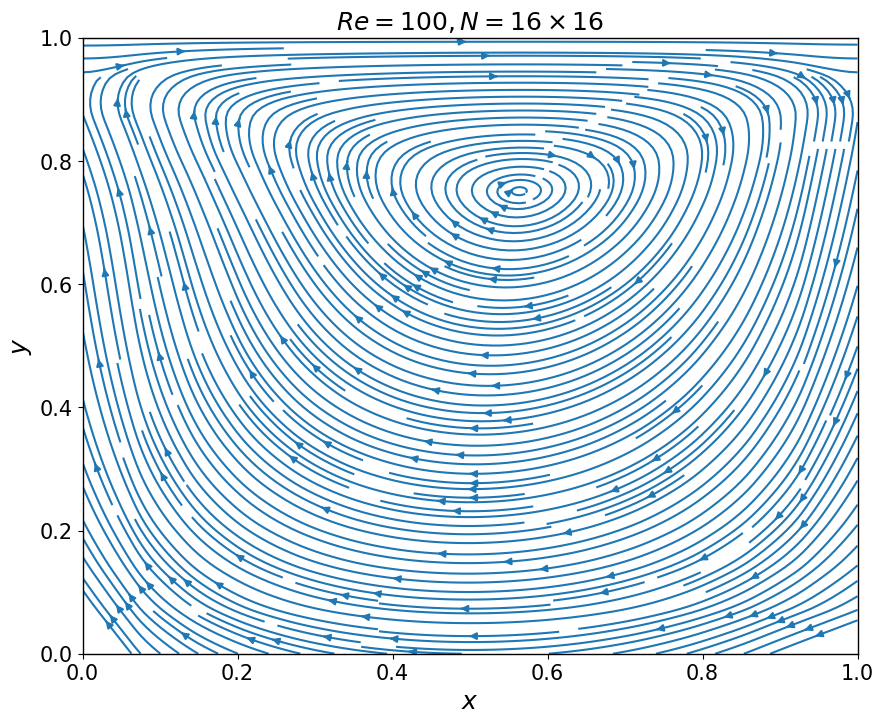

In [8]:
x = np.linspace(0,1,Nx+1)[:,None]
y = np.linspace(0,1,Ny+1)[:,None]
X, Y = np.meshgrid(x, y)
fig = plt.figure(figsize=(10, 8))
plt.streamplot(X,Y,u[:,:,0].T,u[:,:,1].T,density=3)
plt.tick_params(labelsize=15)
plt.xlim(0.0,1.0)
plt.xlabel('$x$', size = 18)
plt.ylabel('$y$', size = 18)
plt.title(r"$Re=100,N = 16 \times 16$", size = 18)
plt.ylim(0.0,1.0)
fig1=plt.gcf()
ax=plt.gca();#获得坐标轴的句柄
ax.spines['bottom'].set_linewidth(1)###设置底部坐标轴的粗细
ax.spines['left'].set_linewidth(1)####设置左边坐标轴的粗细
ax.spines['right'].set_linewidth(1)###设置右边坐标轴的粗细
ax.spines['top'].set_linewidth(1)
#plt.savefig('CLBM——fangqiang32_32——400.jpg', format='jpg',bbox_inches='tight', dpi=200)
plt.show()

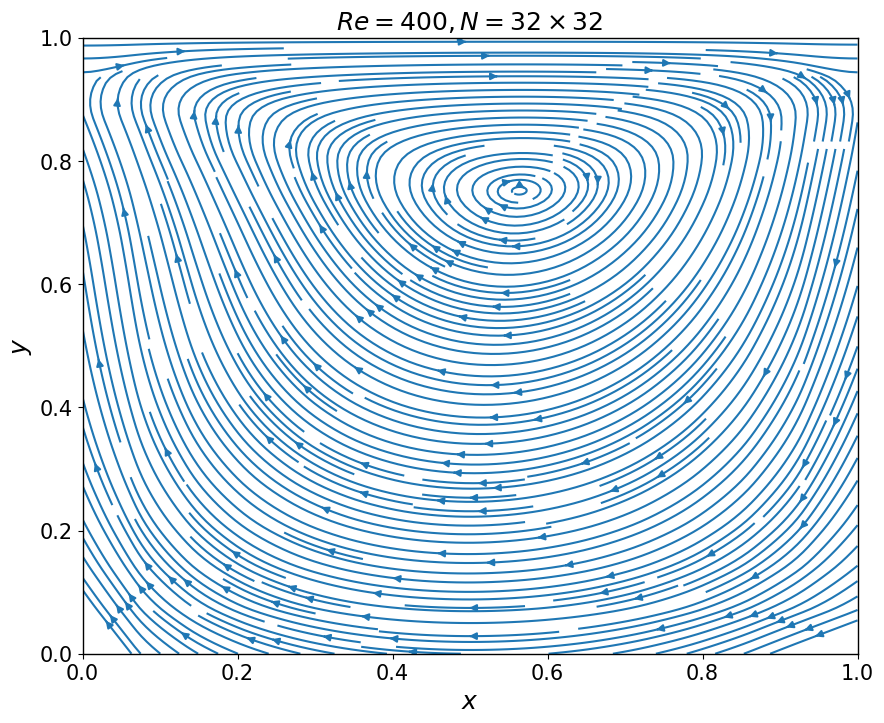

In [9]:
x = np.linspace(0,1,Nx+1)[:,None]
y = np.linspace(0,1,Ny+1)[:,None]
X, Y = np.meshgrid(x, y)
fig = plt.figure(figsize=(10, 8))
plt.streamplot(X,Y,Psi_qlbm1[t,:,:].T,Psi_qlbm2[t,:,:].T,density=3)
plt.tick_params(labelsize=15)
plt.xlim(0.0,1.0)
plt.xlabel('$x$', size = 18)
plt.ylabel('$y$', size = 18)
plt.title(r"$Re=400,N = 32 \times 32$", size = 18)
plt.ylim(0.0,1.0)
fig1=plt.gcf()
ax=plt.gca();#获得坐标轴的句柄
ax.spines['bottom'].set_linewidth(1)###设置底部坐标轴的粗细
ax.spines['left'].set_linewidth(1)####设置左边坐标轴的粗细
ax.spines['right'].set_linewidth(1)###设置右边坐标轴的粗细
ax.spines['top'].set_linewidth(1)
#plt.savefig('QLBM——fangqiang32_32——400.jpg', format='jpg',bbox_inches='tight', dpi=200)
plt.show()

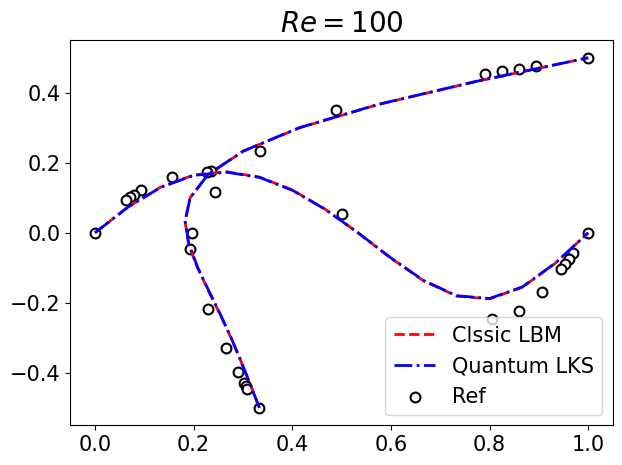

In [11]:
fig = plt.figure(figsize=(7, 5))
plt.title('$Re=100$', size=20)
plt.tick_params(labelsize=15)
x_1 = np.linspace(0,1,Nx+1)

plt.plot((5*(u[int((Nx+1)/2)-1,:,0]+u[int((Nx+1)/2),:,0])+0.5)/3*2,x_1-0.5,'r--',label='Clssic LBM',linewidth = 2,)
plt.plot((5*(Psi_qlbm1[t,int((Nx+1)/2)-1,:]+Psi_qlbm1[t,int((Nx+1)/2),:])+0.5)/3*2,x_1-0.5,'b-.',label='Quantum LKS',linewidth = 2,)

plt.plot(x_1,5*(u[:,int((Nx+1)/2)-1,1]+u[:,int((Nx+1)/2),1]),'r--',linewidth = 2,)
plt.plot(x_1,5*(Psi_qlbm2[t,:,int((Nx+1)/2)-1]+Psi_qlbm2[t,:,int((Nx+1)/2)]),'b-.',linewidth = 2,)

##Re = 100
L1 = np.array([1.0, 0.84123, 0.78871, 0.73722, 0.68717, 0.23151, 0.00332, -0.13641, -0.20581, -0.2109, -0.15662, -0.1015, -0.06434, -0.04775, -0.04192, -0.03717, 0.0])
L2 = np.array([1.0,0.9766,0.9688,0.9609,0.9531,0.8516,0.7344,0.6172,0.5,0.4531,0.2813,0.1717,0.1016,0.0703,0.0625,0.0547,0.0])
L3 = np.array([1.0,0.9688,0.9609,0.9531,0.9453,0.9063,0.8594,0.8047,0.5,0.2344,0.2266,0.1563,0.0938,0.0781,0.0703,0.0625,0.0])
L4 = np.array([0.0,-0.05906,-0.07391,-0.08864,-0.10313,-0.16914,-0.22445,-0.24533,0.05454,0.17527,0.17507,0.16077,0.12317,0.1089,0.10091,0.09233,0.0])
##Re = 400
#L1 = np.array([1.0, 0.75837, 0.68439, 0.61756, 0.55892, 0.29093, 0.16256, 0.02135, -0.11477, -0.17119, -0.32726, -0.24299, -0.14612, -0.10338, -0.09266, -0.08186, 0.0])
#L2 = np.array([1.0,0.9766,0.9688,0.9609,0.9531,0.8516,0.7344,0.6172,0.5,0.4531,0.2813,0.1717,0.1016,0.0703,0.0625,0.0547,0.0])
#L3 = np.array([1.0,0.9688,0.9609,0.9531,0.9453,0.9063,0.8594,0.8047,0.5,0.2344,0.2266,0.1563,0.0938,0.0781,0.0703,0.0625,0.0])
#L4 = np.array([0.0,-0.12146,-0.15663,-0.19254,-0.22847,-0.35827,-0.43993,-0.38598,0.05186,0.30174,0.30203,0.28124,0.22965,0.20920,0.19713,0.18360,0.0])
##Re = 1000
#L1 = np.array([1.0, 0.65928, 0.57492, 0.51117, 0.46604, 0.33304, 0.18719, 0.05702, -0.0608, -0.10648, -0.27805, -0.38289, -0.2973, -0.2222, -0.20196, -0.18109, 0.0])
#L2 = np.array([1.0,0.9766,0.9688,0.9609,0.9531,0.8516,0.7344,0.6172,0.5,0.4531,0.2813,0.1717,0.1016,0.0703,0.0625,0.0547,0.0])
#L3 = np.array([1.0,0.9688,0.9609,0.9531,0.9453,0.9063,0.8594,0.8047,0.5,0.2344,0.2266,0.1563,0.0938,0.0781,0.0703,0.0625,0.0])
#L4 = np.array([0.0,-0.21388,-0.27669,-0.33714,-0.39188,-0.5155,-0.42665,-0.31966,0.02526,0.32235,0.33075,0.37095,0.32627,0.30353,0.29012,0.27485,0.0])
##Re = 5000
#L1 = np.array([1.0, 0.48223, 0.46120, 0.45992, 0.46036, 0.33556, 0.20087, 0.08183, -0.03039, -0.07404, -0.22855, -0.33050, -0.40435, -0.43643, -0.42901, -0.41165, 0.0])
#L2 = np.array([1.0,0.9766,0.9688,0.9609,0.9531,0.8516,0.7344,0.6172,0.5,0.4531,0.2813,0.1717,0.1016,0.0703,0.0625,0.0547,0.0])
#L3 = np.array([1.0,0.9688,0.9609,0.9531,0.9453,0.9063,0.8594,0.8047,0.5,0.2344,0.2266,0.1563,0.0938,0.0781,0.0703,0.0625,0.0])
#L4 = np.array([0.0,-0.49774,-0.55069,-0.55408,-0.52876,-0.41442,-0.36214,-0.30018,0.00945,0.27280,0.28066,0.35368,0.42951,0.43648,0.43329,0.42447,0.0])
##Re = 3200
#L1 = np.array([1.0, 0.53236, 0.48296, 0.46547, 0.46101, 0.34682, 0.19791, 0.07156, -0.04272, -0.086636, -0.24427, -0.34323, -0.41933, -0.37827, -0.35344, -0.32407, 0.0])
#L2 = np.array([1.0,0.9766,0.9688,0.9609,0.9531,0.8516,0.7344,0.6172,0.5,0.4531,0.2813,0.1717,0.1016,0.0703,0.0625,0.0547,0.0])
#L3 = np.array([1.0,0.9688,0.9609,0.9531,0.9453,0.9063,0.8594,0.8047,0.5,0.2344,0.2266,0.1563,0.0938,0.0781,0.0703,0.0625,0.0])
#L4 = np.array([0.0,-0.39017,-0.47425,-0.52357,-0.54053,-0.44307,-0.37401,-0.31184,0.00999,0.28188,0.29030,0.37119,0.42768,0.41906,0.40917,0.39560,0.0])
#plt.scatter(L2, L1, c='',edgecolors='k',marker='o',s = 50,linewidths=1.5,clip_on = False)
plt.scatter(L3, L4, c='w',edgecolors='k',marker='o',s = 50,linewidths=1.5,clip_on = False,label='Ref')
plt.scatter((L1+0.5)/3*2, L2-0.5, c='w',edgecolors='k',marker='o',s = 50,linewidths=1.5,clip_on = False)
plt.legend(loc=0,ncol=1,fontsize=15)
#plt.savefig('Re_100_16.jpg', format='jpg',bbox_inches='tight', dpi=200)
plt.show()